In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
X = pd.read_csv('../data/processed/X.csv')
y = pd.read_csv('../data/processed/y.csv')

In [5]:
X.head()

,Match ID,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,Non Striker,Bowler,...,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Bowler Runs Conceded,Valid Ball,is_six,bowler_wickets,is_dot_ball,Year
0,1359507,9,0,6,1,1,1,442,159,458,...,4,0,1,0,4,1,0,1,0,2023
1,1359507,9,0,6,1,1,2,442,159,458,...,4,0,2,0,0,1,0,1,1,2023
2,1359507,9,0,6,1,1,3,442,159,458,...,4,0,3,0,0,1,0,1,1,2023
3,1359507,9,0,6,1,1,4,442,159,458,...,4,0,4,0,0,1,0,1,1,2023
4,1359507,9,0,6,1,1,5,442,159,458,...,5,0,5,0,1,1,0,1,0,2023


In [6]:
y.head()

,Winner
0,Chennai Super Kings
1,Chennai Super Kings
2,Chennai Super Kings
3,Chennai Super Kings
4,Chennai Super Kings


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier()
model1.fit(X_train,y_train) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

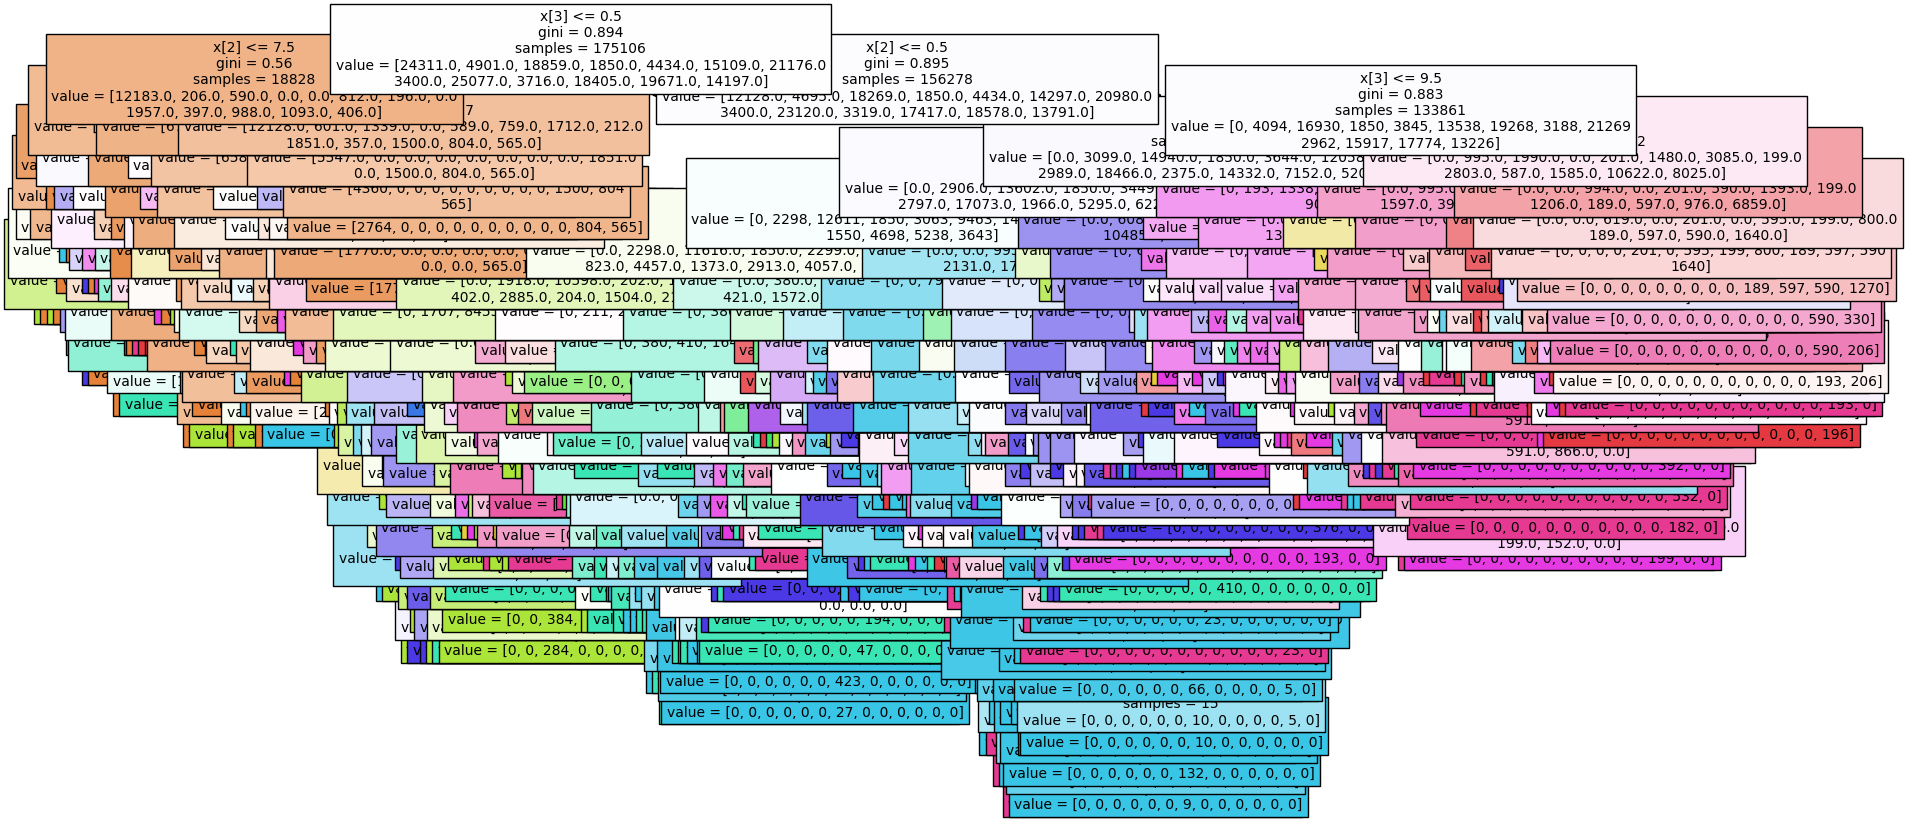

In [9]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    model1,
    filled=True,
    fontsize=10
)
plt.savefig(
    '../visuals/d-tree1.png',
    bbox_inches='tight'
)
plt.show()

Importing Evaluation Metrices - To be used across all the models

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [11]:
y_pred1= model1.predict(X_test)
print("accuracy_score: ", accuracy_score(y_test, y_pred1))

accuracy_score:  0.9999314708636955


In [12]:
X.columns

Index(['Match ID', 'Venue', 'Bat First', 'Bat Second', 'Innings', 'Over',
       'Ball', 'Batter', 'Non Striker', 'Bowler', 'Batter Runs', 'Extra Runs',
       'Runs From Ball', 'Ball Rebowled', 'Extra Type', 'Wicket', 'Method',
       'Innings Runs', 'Innings Wickets', 'Total Batter Runs',
       'Total Non Striker Runs', 'Batter Balls Faced',
       'Non Striker Balls Faced', 'Bowler Runs Conceded', 'Valid Ball',
       'is_six', 'bowler_wickets', 'is_dot_ball', 'Year'],
      dtype='object')

In [13]:
X.drop(columns =['Target Score', 'Runs to Get', 'Balls Remaining', 'Chased Successfully','Target Score', 'Runs to Get', 'Balls Remaining', 'Chased Successfully','bat_first_win_rate', 'bat_second_win_rate'],inplace=True)

KeyError: "['Target Score', 'Runs to Get', 'Balls Remaining', 'Chased Successfully', 'Target Score', 'Runs to Get', 'Balls Remaining', 'Chased Successfully', 'bat_first_win_rate', 'bat_second_win_rate'] not found in axis"

In [14]:
model1_a = DecisionTreeClassifier()
model1_a.fit(X_train,y_train) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

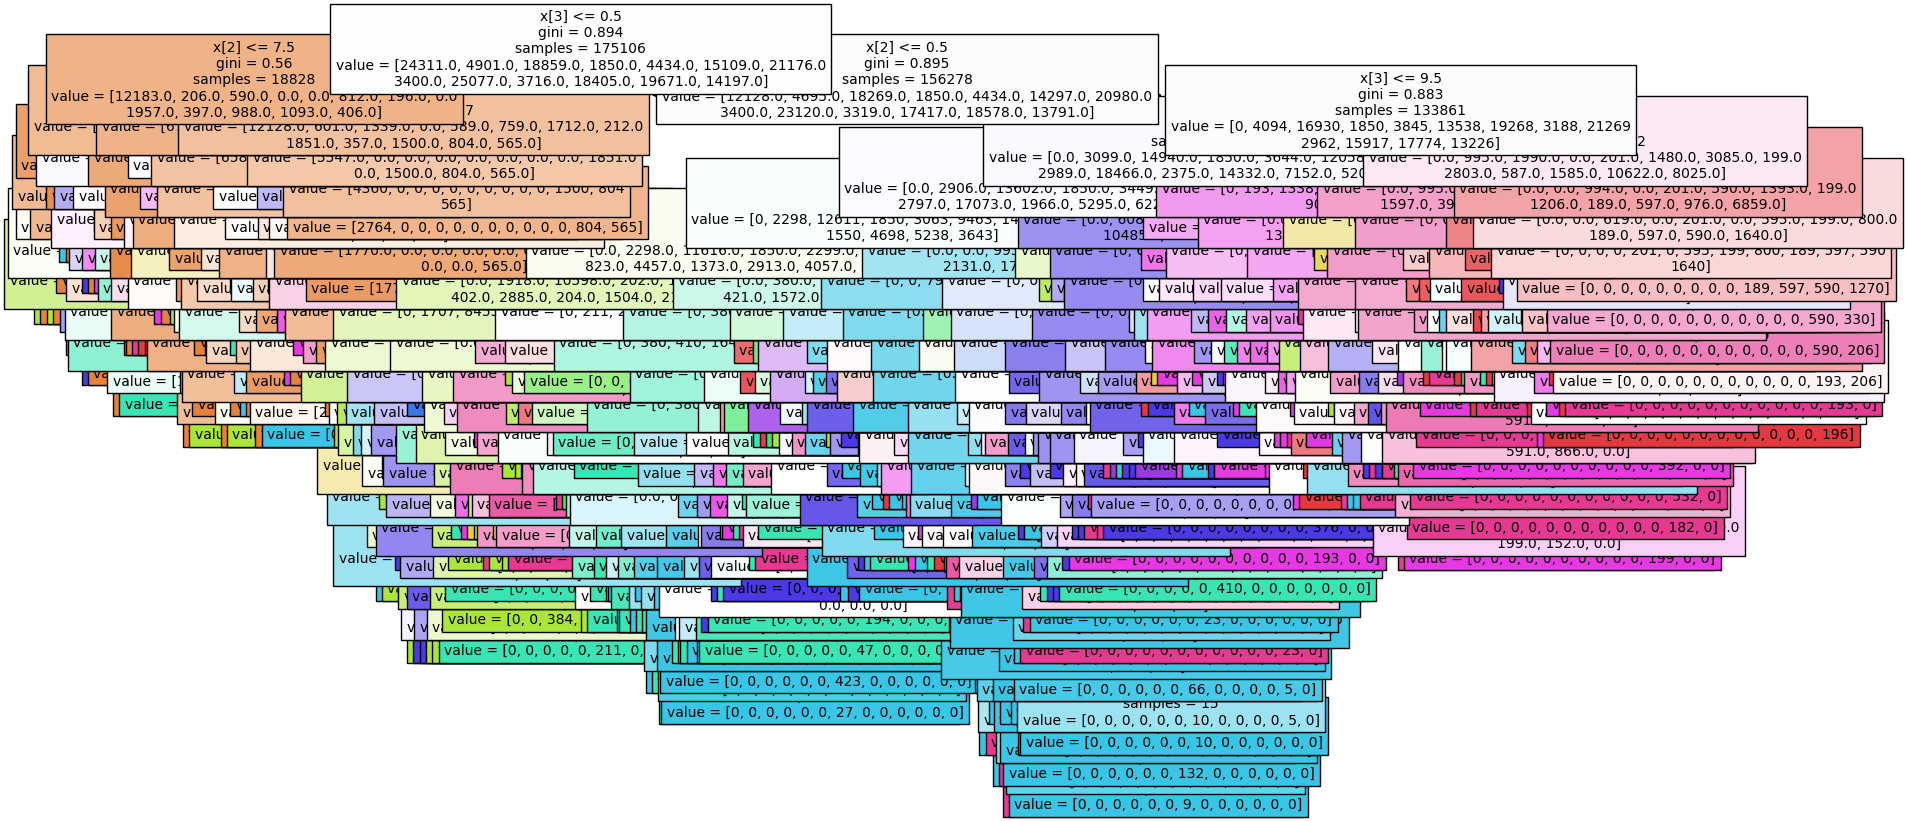

In [15]:
plt.figure(figsize=(20,10))
tree.plot_tree(
    model1_a,
    filled=True,
    fontsize=10
)
plt.savefig(
    '../visuals/d-tree1.png',
    bbox_inches='tight'
)
plt.show()

In [16]:
y_pred1a= model1_a.predict(X_test)
print("accuracy_score: ", accuracy_score(y_test, y_pred1a))

accuracy_score:  0.9999086278182607


In [19]:
groups = X['Match ID']
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(
    test_size=0.2,
    random_state=42
)
train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [20]:
X_train = X_train.drop(columns=['Match ID'])
X_test = X_test.drop(columns=['Match ID'])

In [21]:
X.to_csv('../data/processed/X.csv', index=False)
y.to_csv('../data/processed/y.csv', index=False)

In [22]:
X= pd.read_csv('../data/processed/X.csv')
y= pd.read_csv('../data/processed/y.csv')

In [23]:
model1_b = DecisionTreeClassifier()
model1_b.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [24]:
y_pred1b= model1_b.predict(X_test)
print("accuracy_score: ", accuracy_score(y_test, y_pred1b))

accuracy_score:  0.43351227869788694


In [25]:
print(y.value_counts(normalize=True))

Winner                     
Mumbai Indians                 0.143684
Chennai Super Kings            0.139061
Kolkata Knight Riders          0.120932
Royal Challengers Bangalore    0.112434
Delhi Capitals                 0.107254
Rajasthan Royals               0.105691
Kings XI Punjab                0.085726
Sunrisers Hyderabad            0.081208
Deccan Chargers                0.027631
Gujarat Titans                 0.025411
Punjab Kings                   0.021103
Lucknow Super Giants           0.019165
Gujarat Lions                  0.010700
Name: proportion, dtype: float64


In [26]:
train_acc = model1_b.score(X_train, y_train)
test_acc = model1_b.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9999942892386413
Test Accuracy: 0.43351227869788694


In [27]:
model1_c = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
)
model1_c.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [28]:
y_pred1c= model1_c.predict(X_test)
print("accuracy_score: ", accuracy_score(y_test, y_pred1c))

accuracy_score:  0.3770416904625928


In [29]:
train_acc = model1_c.score(X_train, y_train)
test_acc = model1_c.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.3779096329122599
Test Accuracy: 0.3770416904625928


In [30]:
print(
    classification_report(
        y_test,
        y_pred1c
    )
)

                             precision    recall  f1-score   support

        Chennai Super Kings       0.65      0.57      0.61      6316
            Deccan Chargers       0.20      0.25      0.22       994
             Delhi Capitals       0.77      0.60      0.68      6819
              Gujarat Lions       1.00      1.00      1.00       465
             Gujarat Titans       0.46      0.83      0.59      1469
            Kings XI Punjab       0.08      0.56      0.14      2163
      Kolkata Knight Riders       0.00      0.00      0.00      4742
       Lucknow Super Giants       0.25      1.00      0.40       464
             Mumbai Indians       0.49      0.03      0.06      7064
               Punjab Kings       0.66      0.49      0.56       973
           Rajasthan Royals       0.00      0.00      0.00      4065
Royal Challengers Bangalore       0.40      0.34      0.37      4226
        Sunrisers Hyderabad       0.46      0.76      0.58      4015

                   accuracy     

Importing Evaluation Visuals - To be used across all the models

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

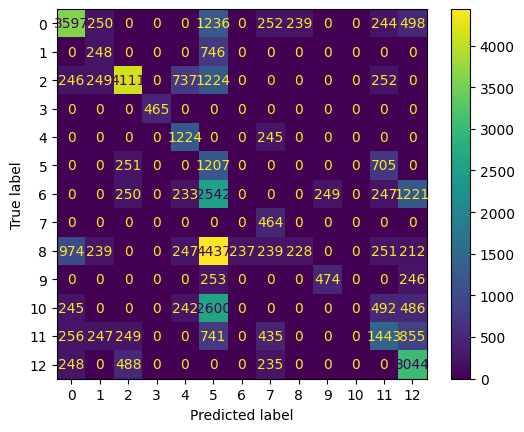

In [32]:
cm = confusion_matrix(y_test, y_pred1c)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

                             precision    recall  f1-score   support

        Chennai Super Kings       0.62      0.82      0.71      6316
            Deccan Chargers       0.29      0.66      0.41       994
             Delhi Capitals       0.77      0.54      0.64      6819
              Gujarat Lions       0.78      1.00      0.88       465
             Gujarat Titans       0.57      0.73      0.64      1469
            Kings XI Punjab       0.17      0.20      0.18      2163
      Kolkata Knight Riders       0.49      0.37      0.42      4742
       Lucknow Super Giants       0.22      1.00      0.36       464
             Mumbai Indians       0.61      0.36      0.45      7064
               Punjab Kings       0.17      0.16      0.17       973
           Rajasthan Royals       0.43      0.41      0.42      4065
Royal Challengers Bangalore       0.39      0.29      0.33      4226
        Sunrisers Hyderabad       0.47      0.66      0.55      4015

                   accuracy     

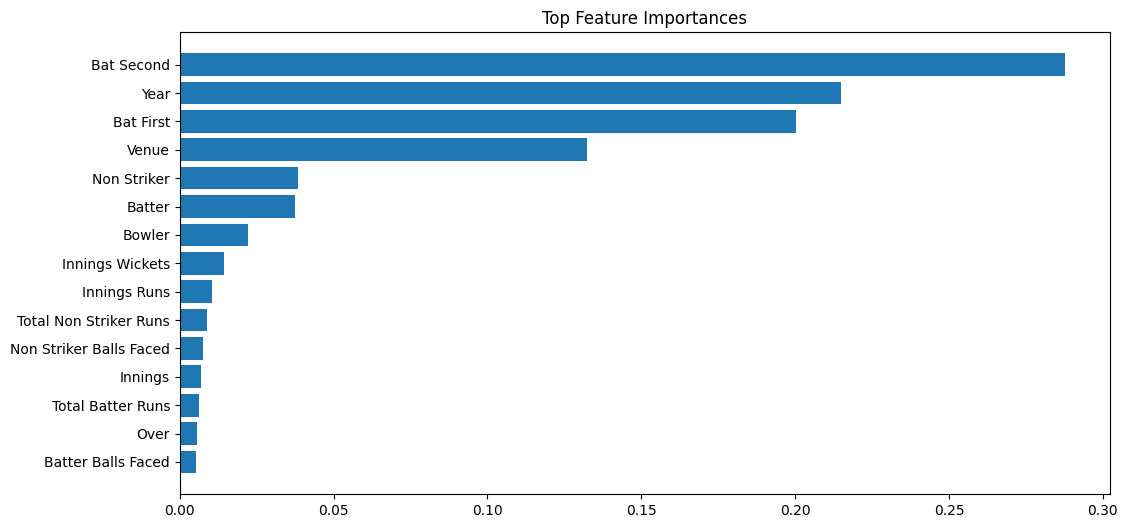

In [35]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)
plt.gca().invert_yaxis()
plt.title('Top Feature Importances')
plt.savefig(
    '../visuals/feature_importance.png',
    bbox_inches='tight'
)
plt.show()

In [36]:
y_prob = rf_model.predict_proba(X_test)
from sklearn.preprocessing import label_binarize
classes = rf_model.classes_
y_test_bin = label_binarize(
    y_test,
    classes=classes
)

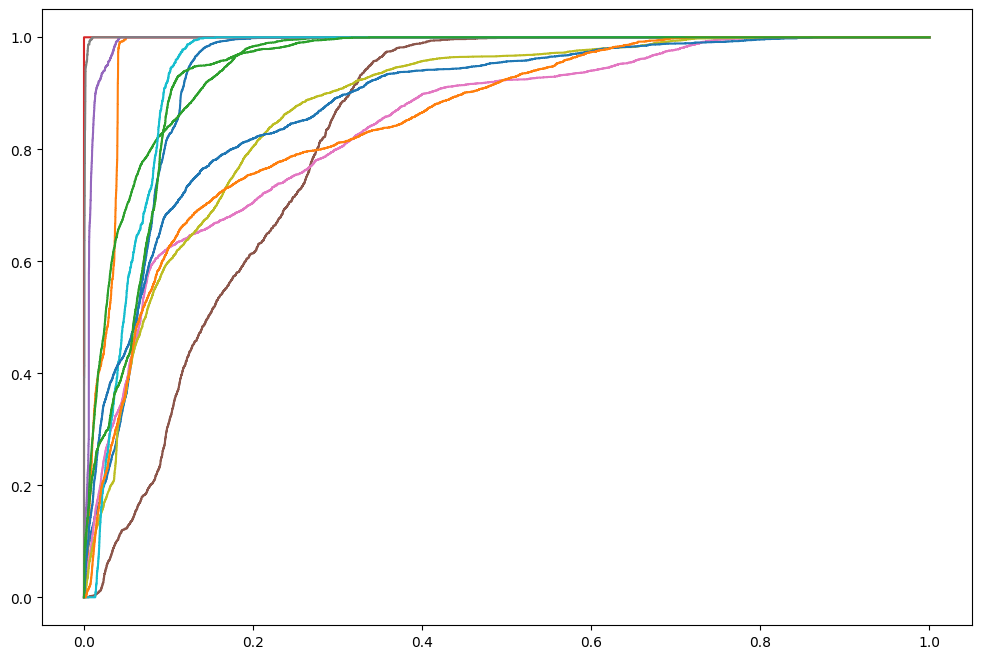

In [37]:
# Plot ROC curve for each class
plt.figure(figsize=(12,8))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f'{class_name} (AUC = {roc_auc:.2f})'
    )
plt.savefig(
    '../visuals/rf_roc_auc_curve_class-wise.png',
    bbox_inches='tight'
)


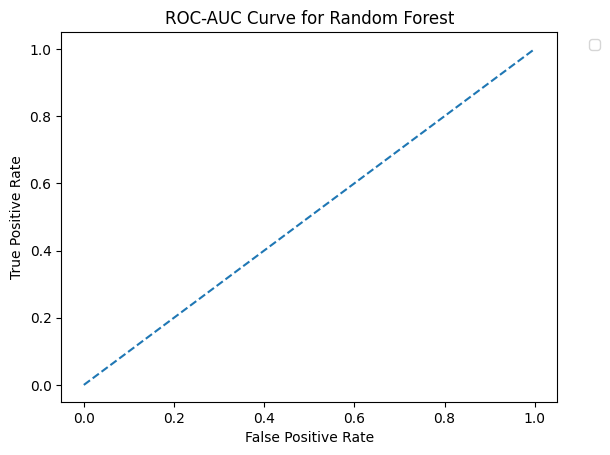

In [38]:
# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC-AUC Curve for Random Forest')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.savefig(
    '../visuals/rf_roc_auc_curve.png',
    bbox_inches='tight'
)

plt.show()

In [39]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [40]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(
    test_size=0.2,
    random_state=42
)
train_idx, test_idx = next(
    gss.split(X, y_encoded, groups=X['Match ID'])
)
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]

In [41]:
!pip3 install xgboost
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    scale_pos_weight=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [42]:
predicted_teams = label_encoder.inverse_transform(xgb_model.predict(X_test))

In [43]:
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.53      0.61      0.57      6316
           1       0.40      0.50      0.45       994
           2       0.69      0.41      0.51      6819
           3       1.00      1.00      1.00       465
           4       0.75      0.50      0.60      1469
           5       0.29      0.45      0.35      2163
           6       0.54      0.54      0.54      4742
           7       1.00      1.00      1.00       464
           8       0.51      0.48      0.50      7064
           9       0.00      0.00      0.00       973
          10       0.39      0.50      0.44      4065
          11       0.27      0.23      0.25      4226
          12       0.37      0.53      0.44      4015

    accuracy                           0.48     43775
   macro avg       0.52      0.52      0.51     43775
weighted avg       0.49      0.48      0.48     43775



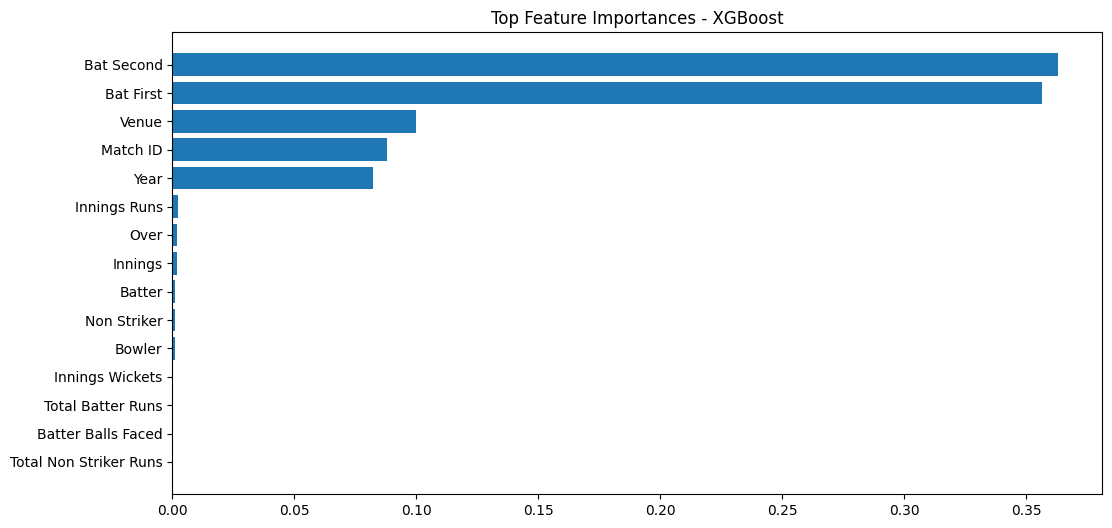

In [44]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.gca().invert_yaxis()

plt.title('Top Feature Importances - XGBoost')

plt.savefig(
    '../visuals/xgb_feature_importance.png',
    bbox_inches='tight'
)
plt.show()

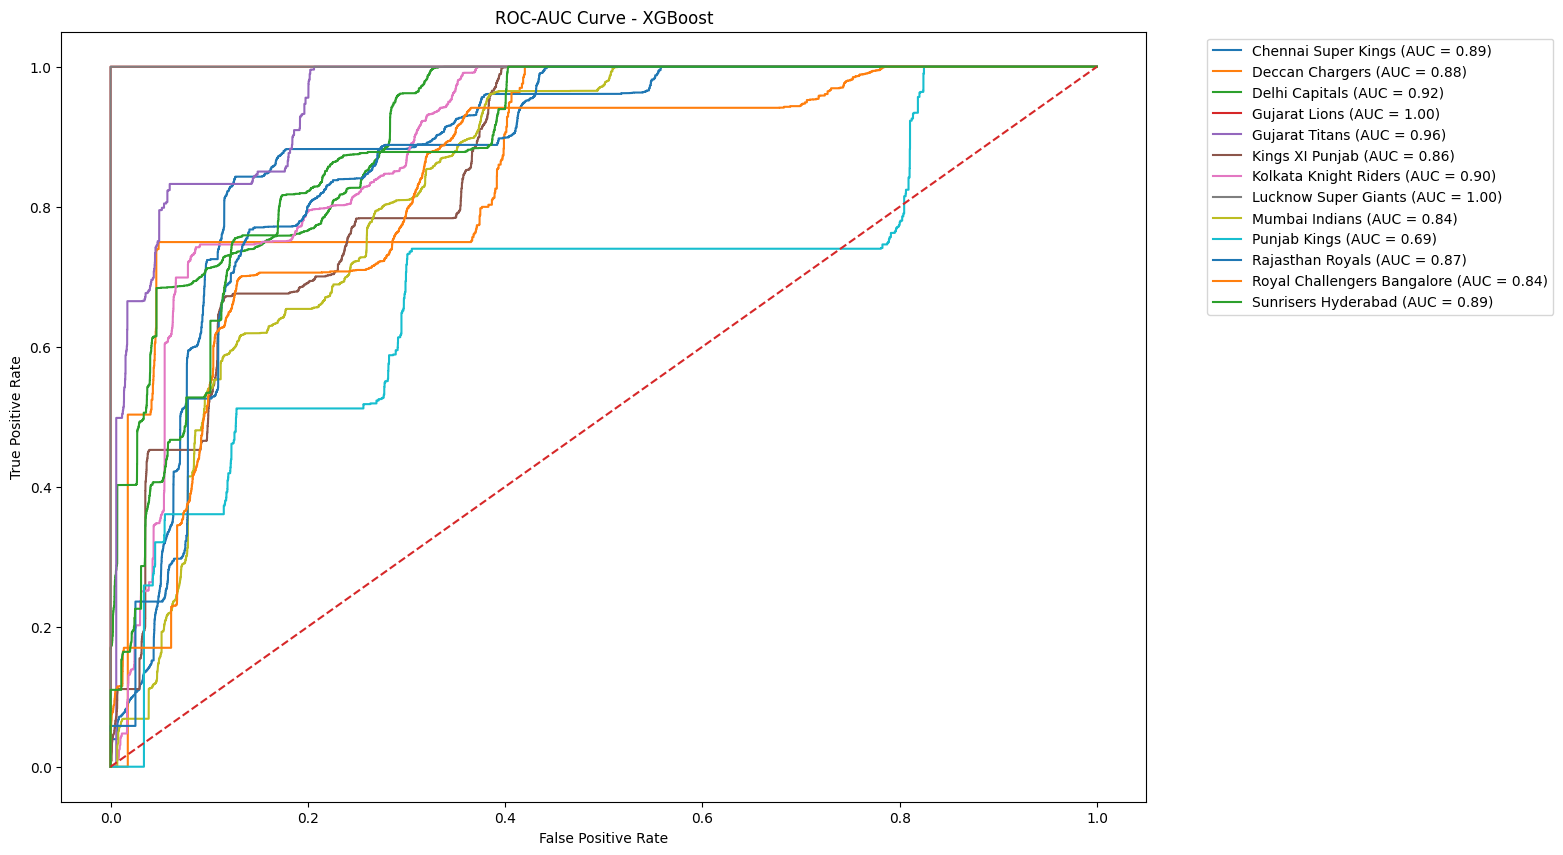

In [45]:
# Convert y_test into binary format
y_test_bin = label_binarize(
    y_test,
    classes=range(len(label_encoder.classes_))
)
# Get probability predictions
y_prob_xgb = xgb_model.predict_proba(X_test)
# Plot ROC curve
plt.figure(figsize=(14,10))
for i, class_name in enumerate(label_encoder.classes_):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_xgb[:, i]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_name} (AUC = {roc_auc:.2f})'
    )
# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC-AUC Curve - XGBoost')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.savefig(
    '../visuals/xgb_roc_auc_curve.png',
    bbox_inches='tight'
)

plt.show()

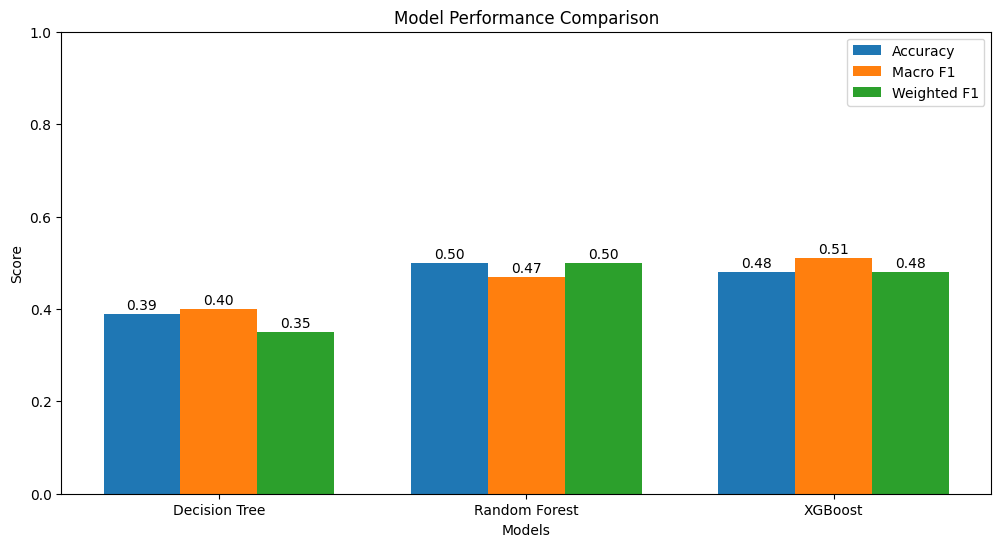

In [46]:
import numpy as np
# Model names
models = [
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]
# Metrics
accuracy = [0.39, 0.50, 0.48]
macro_f1 = [0.40, 0.47, 0.51]
weighted_f1 = [0.35, 0.50, 0.48]
# X-axis positions
x = np.arange(len(models))
width = 0.25
# Create figure
plt.figure(figsize=(12,6))
# Bars
plt.bar(
    x - width,
    accuracy,
    width,
    label='Accuracy'
)
plt.bar(
    x,
    macro_f1,
    width,
    label='Macro F1'
)
plt.bar(
    x + width,
    weighted_f1,
    width,
    label='Weighted F1'
)
# Labels and title
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
# X ticks
plt.xticks(x, models)
# Y-axis limit
plt.ylim(0, 1)
# Add value labels on top
for i, value in enumerate(accuracy):
    plt.text(
        x[i] - width,
        value + 0.01,
        f'{value:.2f}',
        ha='center'
    )
for i, value in enumerate(macro_f1):
    plt.text(
        x[i],
        value + 0.01,
        f'{value:.2f}',
        ha='center'
    )
for i, value in enumerate(weighted_f1):
    plt.text(
        x[i] + width,
        value + 0.01,
        f'{value:.2f}',
        ha='center'
    )
# Legend
plt.legend()

# Save figure
plt.savefig(
    '../visuals/model_performance_comparison.png',
    bbox_inches='tight'
)
# Show plot
plt.show()

Saving models

In [49]:
import joblib
joblib.dump(label_encoder,'../saved_models/label_encoder.pkl')
joblib.dump(model1_c, '../saved_models/decision_tree_model.pkl')
joblib.dump(rf_model, '../saved_models/random_forest_model.pkl')
joblib.dump(xgb_model, '../saved_models/xgboost_model.pkl')

['../saved_models/xgboost_model.pkl']